In [40]:
# import 

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot
import os
import matplotlib.ticker as ticker
import numpy as np
import xarray as xr
import sys

#activate interactive figures
%matplotlib widget
#activate autoreload
%load_ext autoreload

## Add parent directory to syspath
parent_dir = os.path.abspath(os.path.join(os.path.dirname('.'), '..'))
if not parent_dir in sys.path:
    sys.path.append(parent_dir)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:
## Read all data
%autoreload 2
from analyses_level2.read_data import AvailableData, create_data_reader

# File path
data_path = "../data/"

# if New data is added to ./data folder, adapt the dictionary in AvailableData
all_data = list(AvailableData)
#print(all_data)
selected_data = ['CO2', 'CO2_flask', 
                 'CO', 'CO_flask', 
                 'CH4', 'CH4_flask', 
                 'O3'
                 ] # define data to read in. If empty, all data is used 
#selected_data = ['CO2']
## 
processing_kwargs = { 
    'FLASK_FLAG_CORR' : True # exclude flagged flask-data
}

datasets = [] # initialize list of all datasets 
# read in data
for sel in (selected_data if selected_data else all_data):
    #define where the data has to be read from
    data_reader =  create_data_reader(data_path=data_path,dataset=sel,**processing_kwargs) #creates an instance of the desired data_reader class
    print(f"Data from {data_reader.__class__.__name__} for {sel}:")

    # call the data-reading function on that instance: 
    data = data_reader.read_data() 
    # call the data-processing
    data = data_reader.process_data(data)

    # prepare merged dataset
    data = data.drop(columns='endtime') # problem when merging datasets (because of NaT?), so better remove endtime
    ds = data.to_xarray()
    ds = ds.assign_coords(dataset=sel)
    ds['species'] = data_reader.species
    datasets.append(ds)

# save all in one xarray dataset
ds_all = xr.concat(datasets,dim="dataset")


Data from wdcGHGReader for CO2:
Data from wdcFlaskReader for CO2_flask:
Data from wdcGHGReader for CO:
Data from wdcFlaskReader for CO_flask:
Data from wdcGHGReader for CH4:
Data from wdcFlaskReader for CH4_flask:
Data from ebasReader for O3:


In [62]:
ds_all.sel(dataset='O3')

<xarray.Dataset>
Dimensions:             (time: 114106)
Coordinates:
  * time                (time) datetime64[ns] 2002-05-31T23:00:00 ... 2023-12...
    dataset             <U9 'O3'
Data variables: (12/17)
    site_gaw_id         (time) object nan nan nan nan nan ... nan nan nan nan
    value               (time) float64 nan 42.4 40.9 40.14 ... 35.15 32.78 36.53
    value_unc           (time) float64 nan 1.504 1.453 ... 0.9998 2.32 0.7698
    nvalue              (time) float64 nan nan nan nan nan ... nan nan nan nan
    latitude            (time) float64 nan nan nan nan nan ... nan nan nan nan
    longitude           (time) float64 nan nan nan nan nan ... nan nan nan nan
    ...                  ...
    QCflag              (time) float64 nan 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    instrument          (time) float64 nan nan nan nan nan ... nan nan nan nan
    measurement_method  (time) float64 nan nan nan nan nan ... nan nan nan nan
    scale               (time) float64 nan nan nan nan nan ... nan nan nan nan
    unit                (time) object nan 'ppb' 'ppb' ... 'ppb' 'ppb' 'ppb'
    species             <U3 'O3'

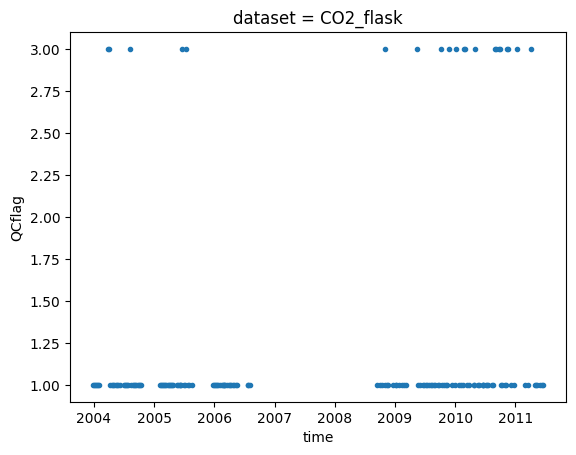

In [13]:
## check flask data
sel_spec = 'CO2_flask'

plt.figure()
ds = ds_all.sel(dataset=sel_spec)
ds = ds.where(~np.isnan(ds.value), drop=True) # remove times where we have no data
ds.QCflag.plot(ls='',marker='.')
plt.show()


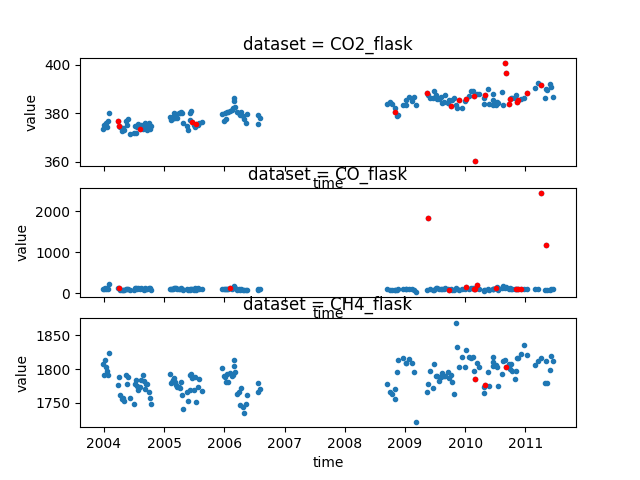

In [41]:
#select all flask species and plot flags: (set 'FLASK_FLAG_CORR' : False)
sel_species = [s for s in selected_data if 'flask' in s]

fig, axs = plt.subplots(len(sel_species),1,sharex=True)
for s,ax in zip(sel_species,axs):
    ds = ds_all.sel(dataset=s)
    ds.value.plot(ax=ax,ls='',marker='.')
    
    # check QCflag = 3
    ds.where(ds.QCflag==3).value.plot(ax=ax,ls='',marker='.',c='r')

    #check original flag (reject if first character is not '.' ) -> gives the same!
    #mask_flag = [str(s)[0] != '.' if isinstance(s, str) else False for s in ds.ORG_QCflag.values]
    #mask_dataarray = xr.DataArray(mask_flag, dims='time', coords={'time': ds['time']})
    #if any(mask_flag):
    #    ds.where(mask_dataarray,drop=True).value.plot(ax=ax,ls='',marker='x',c='g')


In [71]:
np.unique(ds_all.sel(dataset='O3').unit.dropna(dim='time'))

array(['ppb'], dtype=object)

In [75]:
sel_species = ds_all.species 
unique_species = np.unique(sel_species)

fig, axs = plt.subplots(len(unique_species),1,sharex=True)
for s,ax in zip(unique_species,axs):
    ds_sel = ds_all.where(ds_all.species==s,drop=True)
    unit = np.unique(ds_all.sel(dataset=s).unit.dropna(dim='time'))[0]

    #function to plot each subplot
    def plot_data(i_s):
        ds_sel.sel(dataset=i_s).value.plot(ax=ax,ls='',marker='.',alpha=0.7)

    if len(ds_sel.dataset)>1: #several datasets with same species
        for ii in ds_sel.dataset:
            plot_data(ii)
    else:
        plot_data(s)
    
    ax.set_ylabel(f'{ds_sel.species.values[0]} ({unit})')
    ax.set_xlabel('')
    ax.set_title('')
    


#### check ozone  data directly from file

In [ ]:
import nappy
data_path = '../data/wdc/ebas/air/'
for file in os.listdir(data_path):
    if "ozone" in str(file):
       print(file)

file


In [ ]:
%autoreload 2
from processing import ebas
df = ebas.compile_ebas_ozone_data_into_dataframe(data_path,read_unc=True)

In [ ]:
df.index

In [ ]:
pd.to_datetime(df.index[0])#.astype('DateTime64DType')
df.index[0]

In [ ]:
pd.to_datetime(df.index)

In [ ]:
df.to_xarray().O3.plot(marker='o',alpha=0.2,ls='')

In [ ]:
## wdc data: 
from analyses_level2.read_data import AvailableData, create_data_reader

data_path = "../data/"
sel='CO2'
data_reader =  create_data_reader(data_path,sel) #creates an instance of the desired data_reader class
print(f"Data from {data_reader.__class__.__name__} for {sel}:")

# call the data-reading function on that instance: 
data = data_reader.read_data() 

In [ ]:
data.index

In [ ]:
data.index[0]